In [76]:
def extract_page_as_image(pdf_path: str, page_num: int, dpi: int = 300) -> np.ndarray:
    """
    从PDF中提取指定页面为图像
    
    Args:
        pdf_path: PDF文件路径
        page_num: 页面编号（从0开始）
        dpi: 图像分辨率
        
    Returns:
        numpy数组格式的图像（RGB）
    """
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    
    # 设置缩放因子以获得高分辨率图像
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat)
    
    # 转换为numpy数组
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    
    # 如果是RGBA，转换为RGB
    if pix.n == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    elif pix.n == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    doc.close()
    return img


In [77]:
def split_page_into_images(page_img: np.ndarray, rows: int = 2, cols: int = 3) -> List[np.ndarray]:
    """
    将页面图像分割成2行3列的6张图片
    
    Args:
        page_img: 页面图像（numpy数组）
        rows: 行数
        cols: 列数
        
    Returns:
        包含6张图片的列表，按从左到右、从上到下的顺序
    """
    h, w = page_img.shape[:2]
    cell_h = h // rows
    cell_w = w // cols
    
    images = []
    for i in range(rows):
        for j in range(cols):
            y1 = i * cell_h
            y2 = (i + 1) * cell_h
            x1 = j * cell_w
            x2 = (j + 1) * cell_w
            images.append(page_img[y1:y2, x1:x2])
    
    return images


In [78]:
def extract_dominant_colors(img: np.ndarray, n_colors: int = 5, 
                            color_space: str = 'RGB') -> np.ndarray:
    """
    提取图像的主色
    
    Args:
        img: 输入图像（numpy数组，RGB格式）
        n_colors: 要提取的主色数量
        color_space: 颜色空间，'RGB' 或 'LAB'
        
    Returns:
        主色数组，形状为(n_colors, 3)，如果color_space='RGB'返回RGB格式，'LAB'返回LAB格式
    """
    # 将图像重塑为2D数组
    pixels = img.reshape(-1, 3).astype(np.float64)
    
    # 如果需要，转换到LAB颜色空间
    if color_space.upper() == 'LAB':
        if not HAS_SKIMAGE:
            raise ImportError("需要scikit-image库来使用LAB颜色空间。请运行: pip install scikit-image")
        # 归一化RGB到0-1范围（skimage要求）
        pixels_normalized = pixels / 255.0
        # 转换到LAB空间
        pixels_lab = rgb2lab(pixels_normalized.reshape(1, -1, 3)).reshape(-1, 3)
        pixels_for_clustering = pixels_lab
    else:
        pixels_for_clustering = pixels
    
    # 使用KMeans聚类提取主色
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    kmeans.fit(pixels_for_clustering)
    
    # 获取聚类中心（主色）
    dominant_colors = kmeans.cluster_centers_
    
    # 按每个颜色的出现频率排序
    labels = kmeans.labels_
    label_counts = np.bincount(labels)
    sorted_indices = np.argsort(label_counts)[::-1]
    dominant_colors = dominant_colors[sorted_indices]
    
    # 如果是RGB，转换为整数
    if color_space.upper() == 'RGB':
        dominant_colors = dominant_colors.astype(int)
    
    return dominant_colors


In [79]:
def calculate_color_similarity(colors1: np.ndarray, colors2: np.ndarray, 
                               method: str = 'cosine', color_space: str = 'RGB') -> float:
    """
    计算两组主色的相似度（按顺序一一对应匹配）
    
    Args:
        colors1: 第一组主色，形状为(n_colors, 3)
        colors2: 第二组主色，形状为(n_colors, 3)
        method: 相似度计算方法
            - 'cosine': 余弦相似度（仅RGB空间）
            - 'euclidean': 欧氏距离相似度
            - 'delta_e': Delta E（仅LAB空间，更符合人眼感知）
        color_space: 颜色空间，'RGB' 或 'LAB'
        
    Returns:
        相似度分数（0-1之间，越高越相似）
    """
    # 确保两组颜色数量相同
    assert len(colors1) == len(colors2), f"颜色数量必须相同: {len(colors1)} vs {len(colors2)}"
    
    similarities = []
    
    # 按顺序一一对应匹配：第i个颜色对第i个颜色
    for i in range(len(colors1)):
        c1 = colors1[i]
        c2 = colors2[i]
        
        if method == 'delta_e' or (method == 'euclidean' and color_space.upper() == 'LAB'):
            # LAB空间中的Delta E（欧氏距离）
            # Delta E是LAB空间中的标准颜色差异度量
            delta_e = np.linalg.norm(c1 - c2)
            
            # 将Delta E转换为相似度
            # Delta E的范围大致是0-100（人眼可感知的最大差异）
            # 使用sigmoid函数将Delta E转换为0-1的相似度
            # 当Delta E=0时相似度=1，Delta E=50时相似度≈0.5，Delta E=100时相似度≈0
            max_delta_e = 100.0  # LAB空间中合理的最大Delta E
            sim = 1.0 / (1.0 + delta_e / max_delta_e)
            similarities.append(sim)
        
        elif method == 'cosine':
            if color_space.upper() == 'LAB':
                raise ValueError("LAB空间不支持cosine相似度，请使用'delta_e'或'euclidean'")
            # 计算余弦相似度（RGB空间）
            dot_product = np.dot(c1, c2)
            norm1 = np.linalg.norm(c1)
            norm2 = np.linalg.norm(c2)
            if norm1 > 0 and norm2 > 0:
                cos_sim = dot_product / (norm1 * norm2)
                similarities.append(cos_sim)
            else:
                similarities.append(0.0)
        
        elif method == 'euclidean':
            # RGB空间中的欧氏距离相似度
            dist = np.linalg.norm(c1 - c2)
            max_possible_dist = np.sqrt(3 * 255**2)  # RGB空间的最大距离
            sim = 1 - (dist / max_possible_dist)
            similarities.append(max(0.0, sim))  # 确保非负
        
        else:
            raise ValueError(f"Unknown method: {method}. Use 'cosine', 'euclidean', or 'delta_e'.")
    
    # 返回平均相似度
    return np.mean(similarities)


In [80]:
def process_pdf(pdf_path: str, n_colors: int = 5, similarity_method: str = 'cosine', 
                save_results: bool = True, output_dir: str = None,
                dpi: int = 300,
                top_margin: int = 0, bottom_margin: int = 0,
                left_margin: int = 0, right_margin: int = 0,
                row_gap: int = 0, col_gap: int = 0,
                color_space: str = 'RGB') -> Dict:
    """
    处理PDF文件，提取每页的6张图片并比较主色相似度
    
    Args:
        pdf_path: PDF文件路径
        n_colors: 每张图片提取的主色数量
        similarity_method: 相似度计算方法
            - 'cosine': 余弦相似度（仅RGB空间）
            - 'euclidean': 欧氏距离相似度
            - 'delta_e': Delta E（仅LAB空间，更符合人眼感知，推荐）
        save_results: 是否保存结果
        output_dir: 结果保存目录（如果为None，则在PDF同目录下创建）
        dpi: 图像分辨率
        top_margin: 顶部边距（像素）
        bottom_margin: 底部边距（像素）
        left_margin: 左侧边距（像素）
        right_margin: 右侧边距（像素）
        row_gap: 行间距（像素）
        col_gap: 列间距（像素）
        color_space: 颜色空间，'RGB' 或 'LAB'（推荐使用LAB，更符合人眼感知）
        
    Returns:
        包含所有页面结果的字典
    """
    doc = fitz.open(pdf_path)
    num_pages = len(doc)
    doc.close()
    
    results = {
        'pdf_path': pdf_path,
        'num_pages': num_pages,
        'similarity_method': similarity_method,
        'color_space': color_space,
        'dpi': dpi,
        'margins': {
            'top_margin': top_margin,
            'bottom_margin': bottom_margin,
            'left_margin': left_margin,
            'right_margin': right_margin,
            'row_gap': row_gap,
            'col_gap': col_gap
        },
        'pages': []
    }
    
    print(f"开始处理PDF: {pdf_path}")
    print(f"总页数: {num_pages}")
    print(f"颜色空间: {color_space}")
    print(f"相似度方法: {similarity_method}")
    print(f"边界参数: top={top_margin}, bottom={bottom_margin}, left={left_margin}, right={right_margin}")
    print(f"间距参数: row_gap={row_gap}, col_gap={col_gap}")
    
    for page_num in range(num_pages):
        print(f"\n处理第 {page_num + 1}/{num_pages} 页...")
        
        # 提取页面为图像
        page_img = extract_page_as_image(pdf_path, page_num, dpi)
        
        # 使用带边界参数的分割函数
        images = split_page_with_margins(page_img, rows=2, cols=3,
                                        top_margin=top_margin, bottom_margin=bottom_margin,
                                        left_margin=left_margin, right_margin=right_margin,
                                        row_gap=row_gap, col_gap=col_gap)
        
        if len(images) != 6:
            print(f"警告: 第 {page_num + 1} 页没有提取到6张图片，跳过")
            continue
        
        # 第一张是原始图像
        original_img = images[0]
        original_colors = extract_dominant_colors(original_img, n_colors, color_space=color_space)
        
        # 后续5张是重建图像
        reconstructed_imgs = images[1:6]
        page_result = {
            'page_num': page_num + 1,
            'original_colors': original_colors.tolist(),
            'reconstructions': []
        }
        
        # 对每张重建图像计算相似度
        for idx, recon_img in enumerate(reconstructed_imgs):
            recon_colors = extract_dominant_colors(recon_img, n_colors, color_space=color_space)
            similarity = calculate_color_similarity(original_colors, recon_colors, 
                                                  method=similarity_method, 
                                                  color_space=color_space)
            
            page_result['reconstructions'].append({
                'image_idx': idx + 1,
                'colors': recon_colors.tolist(),
                'similarity': float(similarity)
            })
            
            print(f"  重建图像 {idx + 1}: 相似度 = {similarity:.4f}")
        
        results['pages'].append(page_result)
    
    # 保存结果
    if save_results:
        if output_dir is None:
            output_dir = os.path.dirname(pdf_path)
        
        import json
        output_file = os.path.join(output_dir, 
                                   os.path.splitext(os.path.basename(pdf_path))[0] + '_color_similarity.json')
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(results, f, ensure_ascii=False, indent=2)
        print(f"\n结果已保存到: {output_file}")
    
    return results


## 测试代码：确定图片范围

首先使用下面的代码测试并确定6张图片的准确范围。可以调整边界参数（margins）直到分割正确。


In [67]:
def test_page_split(pdf_path: str, page_num: int = 0, dpi: int = 300,
                    top_margin: int = 0, bottom_margin: int = 0,
                    left_margin: int = 0, right_margin: int = 0,
                    row_gap: int = 0, col_gap: int = 0,
                    show_original: bool = True, show_grid: bool = True):
    """
    测试页面分割，可视化显示分割结果
    
    Args:
        pdf_path: PDF文件路径
        page_num: 页面编号（从0开始）
        dpi: 图像分辨率
        top_margin: 顶部边距（像素）
        bottom_margin: 底部边距（像素）
        left_margin: 左侧边距（像素）
        right_margin: 右侧边距（像素）
        row_gap: 行间距（像素）
        col_gap: 列间距（像素）
        show_original: 是否显示原始页面图像
        show_grid: 是否在原始图像上显示网格线
    """
    # 提取页面
    page_img = extract_page_as_image(pdf_path, page_num, dpi)
    h, w = page_img.shape[:2]
    
    print(f"页面尺寸: {w} x {h} 像素")
    print(f"当前参数:")
    print(f"  顶部边距: {top_margin} 像素")
    print(f"  底部边距: {bottom_margin} 像素")
    print(f"  左侧边距: {left_margin} 像素")
    print(f"  右侧边距: {right_margin} 像素")
    print(f"  行间距: {row_gap} 像素")
    print(f"  列间距: {col_gap} 像素")
    
    # 分割图片
    images = split_page_with_margins(page_img, rows=2, cols=3,
                                     top_margin=top_margin, bottom_margin=bottom_margin,
                                     left_margin=left_margin, right_margin=right_margin,
                                     row_gap=row_gap, col_gap=col_gap)
    
    # 创建可视化
    if show_original:
        from matplotlib.gridspec import GridSpec
        fig = plt.figure(figsize=(22, 12), facecolor='black')
        # 改成2行5列：左侧2列给原始页面，右侧3列给6张图片（2行3列）
        # width_ratios: [列0, 列1, 列2, 列3, 列4] = [原始页面左, 原始页面右, 图片1, 图片2, 图片3]
        gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 1], hspace=0.3, wspace=0.3)
        
        # 显示原始页面（带网格线）- 占据左侧2列
        ax1 = fig.add_subplot(gs[:, 0:2])
        ax1.imshow(page_img)
        ax1.axis('off')
        
        if show_grid:
            # 绘制网格线
            available_h = h - top_margin - bottom_margin
            available_w = w - left_margin - right_margin
            total_row_gaps = (2 - 1) * row_gap
            total_col_gaps = (3 - 1) * col_gap
            cell_h = (available_h - total_row_gaps) // 2
            cell_w = (available_w - total_col_gaps) // 3
            
            # 绘制垂直分割线（4条：左右边界+中间2条）
            # 左边界
            ax1.axvline(left_margin, color='red', linewidth=2, linestyle='--', alpha=0.7)
            # 中间两条垂直分割线
            for i in range(1, 3):
                x = left_margin + i * (cell_w + col_gap)
                ax1.axvline(x, color='red', linewidth=2, linestyle='--', alpha=0.7)
            # 右边界
            ax1.axvline(left_margin + 3 * cell_w + 2 * col_gap, color='red', linewidth=2, linestyle='--', alpha=0.7)
            
            # 绘制水平分割线（3条：上下边界+中间1条）
            # 上边界
            ax1.axhline(top_margin, color='red', linewidth=2, linestyle='--', alpha=0.7)
            # 中间水平分割线
            ax1.axhline(top_margin + cell_h + row_gap, color='red', linewidth=2, linestyle='--', alpha=0.7)
            # 下边界
            ax1.axhline(top_margin + 2 * cell_h + row_gap, color='red', linewidth=2, linestyle='--', alpha=0.7)
        
        # 显示分割后的6张图片 - 右侧3列（索引2,3,4），分2行
        titles = ['1', '2', '3', 
                 '4', '5', '6']
        
        for idx, (img, title) in enumerate(zip(images, titles)):
            row = idx // 3
            col = idx % 3
            ax = fig.add_subplot(gs[row, col + 2])  # col+2: 2,3,4
            ax.imshow(img)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        # 只显示分割后的6张图片
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        titles = ['1', '2', '3', 
                 '4', '5', '6']
        
        for idx, (img, title) in enumerate(zip(images, titles)):
            row = idx // 3
            col = idx % 3
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    
    return images, {
        'top_margin': top_margin,
        'bottom_margin': bottom_margin,
        'left_margin': left_margin,
        'right_margin': right_margin,
        'row_gap': row_gap,
        'col_gap': col_gap,
        'page_size': (w, h)
    }


页面尺寸: 4500 x 3000 像素
当前参数:
  顶部边距: 270 像素
  底部边距: 50 像素
  左侧边距: 130 像素
  右侧边距: 120 像素
  行间距: 155 像素
  列间距: 240 像素


/tmp/ipykernel_934660/383011581.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


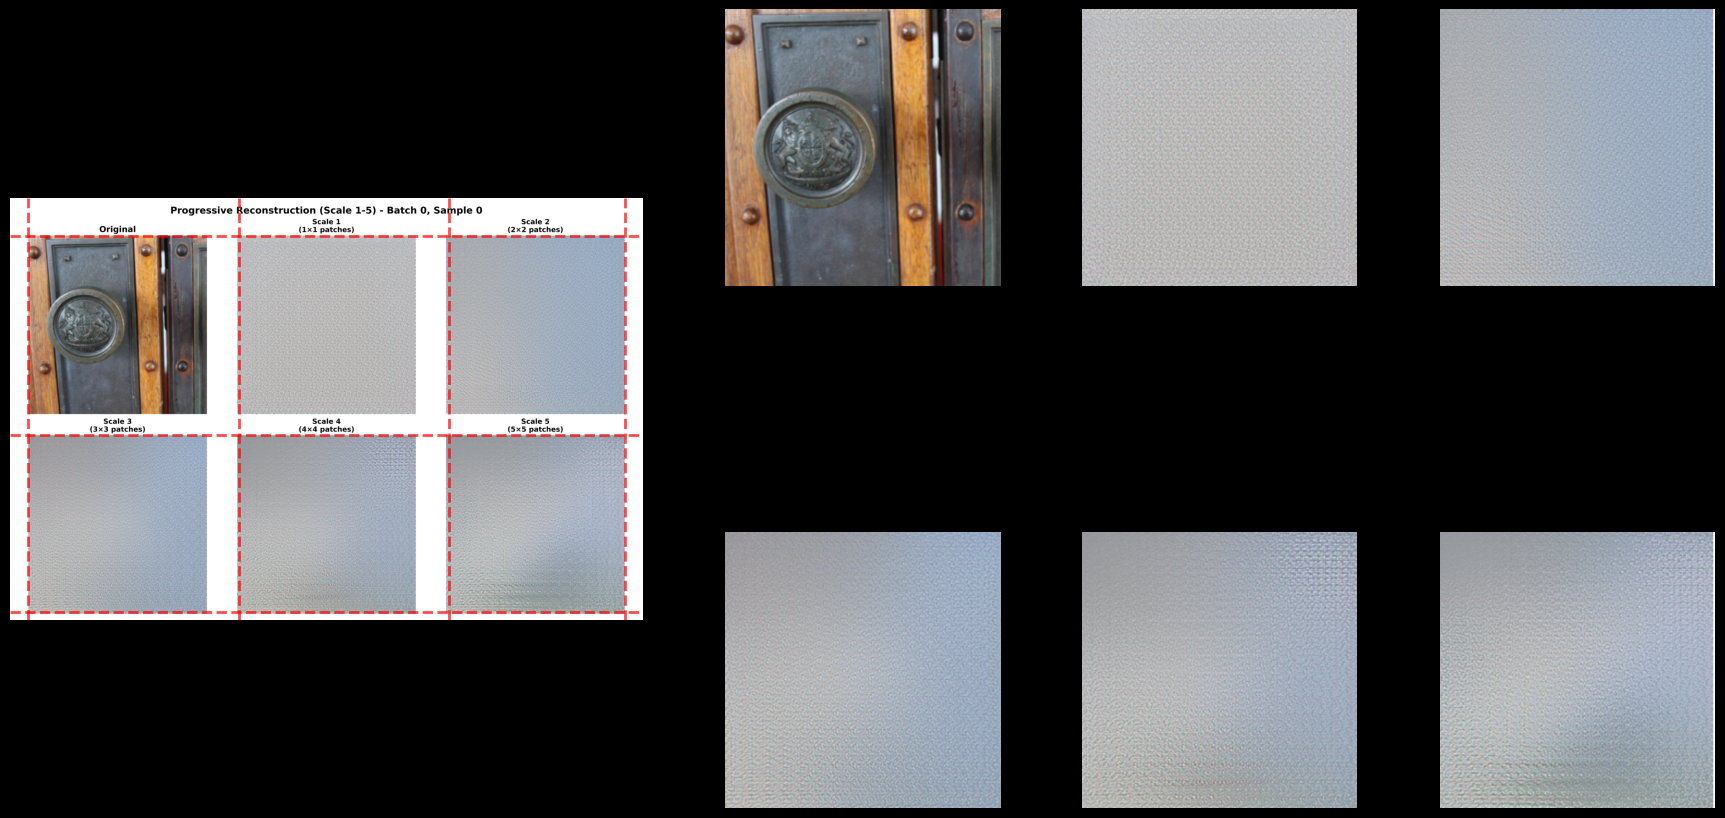

In [71]:
# ====== 请在这里设置你的PDF路径和参数 ======
pdf_path = "/home/ubuntu/Desktop/reconstruction_results_train_scale1.pdf"  # 请修改为你的PDF文件路径
page_num = 0  # 要测试的页面编号（从0开始，通常是第一页）

# 边界参数（单位：像素，可以根据DPI调整）
# 初始值可以先设为0，然后根据可视化结果调整
top_margin = 270      # 顶部边距
bottom_margin = 50   # 底部边距
left_margin = 130     # 左侧边距
right_margin = 120    # 右侧边距
row_gap =155         # 行间距（两张图片之间的垂直间距）
col_gap = 240         # 列间距（两张图片之间的水平间距）

# DPI设置（越高分辨率越高，但处理时间更长）
dpi = 300

# ====== 运行测试 ======
images, params = test_page_split(
    pdf_path=pdf_path,
    page_num=page_num,
    dpi=dpi,
    top_margin=top_margin,
    bottom_margin=bottom_margin,
    left_margin=left_margin,
    right_margin=right_margin,
    row_gap=row_gap,
    col_gap=col_gap,
    show_original=True,
    show_grid=True
)




## 正式处理：计算主色相似度

使用测试得到的参数进行正式处理。

**推荐使用LAB颜色空间和Delta E方法**，因为：
- LAB颜色空间更符合人眼对颜色的感知
- Delta E是标准的颜色差异度量，更准确
- 可以避免RGB空间中cosine相似度可能虚高的问题

如果未安装scikit-image，请运行：`pip install scikit-image`


In [81]:
# ====== 设置PDF路径和参数（使用测试得到的参数） ======
pdf_path = "/home/ubuntu/Desktop/reconstruction_results_train_scale1.pdf"  # PDF文件路径

# 使用测试得到的边界参数
top_margin = 270      # 顶部边距
bottom_margin = 50    # 底部边距
left_margin = 130      # 左侧边距
right_margin = 120     # 右侧边距
row_gap = 155         # 行间距
col_gap = 240         # 列间距
dpi = 300             # DPI（与测试时保持一致）

# 相似度计算参数
n_colors = 5           # 每张图片提取的主色数量

# 推荐使用LAB颜色空间和Delta E方法（更符合人眼感知）
color_space = 'LAB'    # 颜色空间：'RGB' 或 'LAB'（推荐LAB）
similarity_method = 'delta_e'  # 相似度计算方法：
                                # - 'delta_e': Delta E（仅LAB空间，推荐）
                                # - 'cosine': 余弦相似度（仅RGB空间）
                                # - 'euclidean': 欧氏距离相似度

# ====== 运行处理 ======
results = process_pdf(
    pdf_path=pdf_path,
    n_colors=n_colors,
    similarity_method=similarity_method,
    color_space=color_space,  # 使用LAB颜色空间
    dpi=dpi,
    top_margin=top_margin,
    bottom_margin=bottom_margin,
    left_margin=left_margin,
    right_margin=right_margin,
    row_gap=row_gap,
    col_gap=col_gap,
    save_results=True
)


开始处理PDF: /home/ubuntu/Desktop/reconstruction_results_train_scale1.pdf
总页数: 84
颜色空间: LAB
相似度方法: delta_e
边界参数: top=270, bottom=50, left=130, right=120
间距参数: row_gap=155, col_gap=240

处理第 1/84 页...
  重建图像 1: 相似度 = 0.7320
  重建图像 2: 相似度 = 0.7327
  重建图像 3: 相似度 = 0.7428
  重建图像 4: 相似度 = 0.7414
  重建图像 5: 相似度 = 0.7376

处理第 2/84 页...
  重建图像 1: 相似度 = 0.7835
  重建图像 2: 相似度 = 0.7683
  重建图像 3: 相似度 = 0.7734
  重建图像 4: 相似度 = 0.7873
  重建图像 5: 相似度 = 0.7780

处理第 3/84 页...
  重建图像 1: 相似度 = 0.7376
  重建图像 2: 相似度 = 0.7461
  重建图像 3: 相似度 = 0.7545
  重建图像 4: 相似度 = 0.7743
  重建图像 5: 相似度 = 0.7639

处理第 4/84 页...
  重建图像 1: 相似度 = 0.7003
  重建图像 2: 相似度 = 0.7214
  重建图像 3: 相似度 = 0.6992
  重建图像 4: 相似度 = 0.6972
  重建图像 5: 相似度 = 0.6832

处理第 5/84 页...
  重建图像 1: 相似度 = 0.7490
  重建图像 2: 相似度 = 0.6803
  重建图像 3: 相似度 = 0.7300
  重建图像 4: 相似度 = 0.7108
  重建图像 5: 相似度 = 0.6635

处理第 6/84 页...
  重建图像 1: 相似度 = 0.7375
  重建图像 2: 相似度 = 0.7234
  重建图像 3: 相似度 = 0.7549
  重建图像 4: 相似度 = 0.7175
  重建图像 5: 相似度 = 0.7379

处理第 7/84 页...
  重建图像 1: 相似度 = 0.7124
  

In [82]:
def calculate_random_similarity_baseline(n_colors: int = 5, n_samples: int = 1000, 
                                        method: str = 'cosine', color_space: str = 'RGB', 
                                        seed: int = 42) -> Dict:
    """
    计算随机颜色之间的相似度基准，用于对比验证
    
    Args:
        n_colors: 每组主色的数量（与提取的主色数量一致）
        n_samples: 采样次数（计算多少次随机相似度）
        method: 相似度计算方法
        color_space: 颜色空间，'RGB' 或 'LAB'
        seed: 随机种子
        
    Returns:
        包含随机相似度统计信息的字典
    """
    np.random.seed(seed)
    
    random_similarities = []
    
    for _ in range(n_samples):
        # 生成两组随机颜色（RGB值在0-255之间）
        colors1_rgb = np.random.randint(0, 256, size=(n_colors, 3), dtype=np.uint8)
        colors2_rgb = np.random.randint(0, 256, size=(n_colors, 3), dtype=np.uint8)
        
        # 如果需要，转换到LAB颜色空间
        if color_space.upper() == 'LAB':
            if not HAS_SKIMAGE:
                raise ImportError("需要scikit-image库来使用LAB颜色空间。请运行: pip install scikit-image")
            # 归一化RGB到0-1范围
            colors1_norm = colors1_rgb.astype(np.float64) / 255.0
            colors2_norm = colors2_rgb.astype(np.float64) / 255.0
            # 转换到LAB空间
            colors1 = rgb2lab(colors1_norm.reshape(1, -1, 3)).reshape(-1, 3)
            colors2 = rgb2lab(colors2_norm.reshape(1, -1, 3)).reshape(-1, 3)
        else:
            colors1 = colors1_rgb
            colors2 = colors2_rgb
        
        # 计算相似度
        similarity = calculate_color_similarity(colors1, colors2, method=method, color_space=color_space)
        random_similarities.append(similarity)
    
    random_similarities = np.array(random_similarities)
    
    result = {
        'n_samples': n_samples,
        'n_colors': n_colors,
        'method': method,
        'color_space': color_space,
        'mean': float(np.mean(random_similarities)),
        'std': float(np.std(random_similarities)),
        'min': float(np.min(random_similarities)),
        'max': float(np.max(random_similarities)),
        'median': float(np.median(random_similarities)),
        'percentiles': {
            '5th': float(np.percentile(random_similarities, 5)),
            '25th': float(np.percentile(random_similarities, 25)),
            '75th': float(np.percentile(random_similarities, 75)),
            '95th': float(np.percentile(random_similarities, 95)),
        },
        'all_similarities': random_similarities.tolist()
    }
    
    print(f"\n=== 随机颜色相似度基准 (n={n_samples}) ===")
    print(f"颜色空间: {color_space}")
    print(f"方法: {method}")
    print(f"每组主色数: {n_colors}")
    print(f"平均相似度: {result['mean']:.4f}")
    print(f"标准差: {result['std']:.4f}")
    print(f"最小值: {result['min']:.4f}")
    print(f"最大值: {result['max']:.4f}")
    print(f"中位数: {result['median']:.4f}")
    print(f"5%分位数: {result['percentiles']['5th']:.4f}")
    print(f"95%分位数: {result['percentiles']['95th']:.4f}")
    
    return result


def compare_with_random_baseline(results: Dict, baseline: Dict = None, 
                                 n_samples: int = 1000, visualize: bool = True):
    """
    将真实结果与随机基准进行对比
    
    Args:
        results: process_pdf返回的结果字典
        baseline: 随机基准结果（如果为None，则自动计算）
        n_samples: 如果baseline为None，用于计算基准的采样次数
        visualize: 是否可视化对比
    """
    # 收集所有真实相似度
    real_similarities = []
    for page_result in results['pages']:
        for recon in page_result['reconstructions']:
            real_similarities.append(recon['similarity'])
    real_similarities = np.array(real_similarities)
    
    # 如果没有提供基准，计算一个
    if baseline is None:
        n_colors = 5  # 可以从results中推断，但这里假设是5
        # 从results中获取color_space，如果没有则默认为RGB
        color_space = results.get('color_space', 'RGB')
        baseline = calculate_random_similarity_baseline(
            n_colors=n_colors,
            n_samples=n_samples,
            method=results['similarity_method'],
            color_space=color_space
        )
    
    # 打印对比结果
    print(f"\n{'='*50}")
    print(f"真实结果 vs 随机基准对比")
    print(f"{'='*50}")
    print(f"真实结果:")
    print(f"  平均相似度: {np.mean(real_similarities):.4f} (vs 随机: {baseline['mean']:.4f})")
    print(f"  标准差: {np.std(real_similarities):.4f} (vs 随机: {baseline['std']:.4f})")
    print(f"  最小值: {np.min(real_similarities):.4f} (vs 随机: {baseline['min']:.4f})")
    print(f"  最大值: {np.max(real_similarities):.4f} (vs 随机: {baseline['max']:.4f})")
    print(f"  中位数: {np.median(real_similarities):.4f} (vs 随机: {baseline['median']:.4f})")
    
    # 计算统计显著性（Z-test）
    z_score = (np.mean(real_similarities) - baseline['mean']) / baseline['std'] * np.sqrt(len(real_similarities))
    print(f"\n统计检验:")
    print(f"  Z-score: {z_score:.2f}")
    print(f"  (Z-score > 2 表示真实结果显著高于随机，> 3 表示非常显著)")
    
    if visualize:
        # 可视化对比
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # 1. 直方图对比
        axes[0].hist(real_similarities, bins=50, alpha=0.7, label='真实结果', color='blue', density=True)
        axes[0].hist(baseline['all_similarities'], bins=50, alpha=0.7, label='随机基准', color='red', density=True)
        axes[0].axvline(np.mean(real_similarities), color='blue', linestyle='--', linewidth=2, label=f'真实均值: {np.mean(real_similarities):.3f}')
        axes[0].axvline(baseline['mean'], color='red', linestyle='--', linewidth=2, label=f'随机均值: {baseline["mean"]:.3f}')
        axes[0].set_xlabel('相似度', fontsize=12)
        axes[0].set_ylabel('密度', fontsize=12)
        axes[0].set_title('真实结果 vs 随机基准分布', fontsize=14)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. 箱线图对比
        data_to_plot = [real_similarities, np.array(baseline['all_similarities'])]
        axes[1].boxplot(data_to_plot, labels=['真实结果', '随机基准'])
        axes[1].set_ylabel('相似度', fontsize=12)
        axes[1].set_title('相似度分布对比（箱线图）', fontsize=14)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'real_mean': float(np.mean(real_similarities)),
        'real_std': float(np.std(real_similarities)),
        'baseline_mean': baseline['mean'],
        'baseline_std': baseline['std'],
        'z_score': float(z_score),
        'ratio': float(np.mean(real_similarities) / baseline['mean'])
    }


=== 随机颜色相似度基准 (n=10000) ===
颜色空间: LAB
方法: delta_e
每组主色数: 5
平均相似度: 0.5711
标准差: 0.0566
最小值: 0.3859
最大值: 0.8077
中位数: 0.5689
5%分位数: 0.4811
95%分位数: 0.6673

真实结果 vs 随机基准对比
真实结果:
  平均相似度: 0.7340 (vs 随机: 0.5711)
  标准差: 0.0439 (vs 随机: 0.0566)
  最小值: 0.6070 (vs 随机: 0.3859)
  最大值: 0.8746 (vs 随机: 0.8077)
  中位数: 0.7370 (vs 随机: 0.5689)

统计检验:
  Z-score: 59.02
  (Z-score > 2 表示真实结果显著高于随机，> 3 表示非常显著)


/tmp/ipykernel_934660/3178623473.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['真实结果', '随机基准'])
/tmp/ipykernel_934660/3178623473.py:149: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_934660/3178623473.py:149: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_934660/3178623473.py:149: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_934660/3178623473.py:149: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_934660/3178623473.py:149: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(

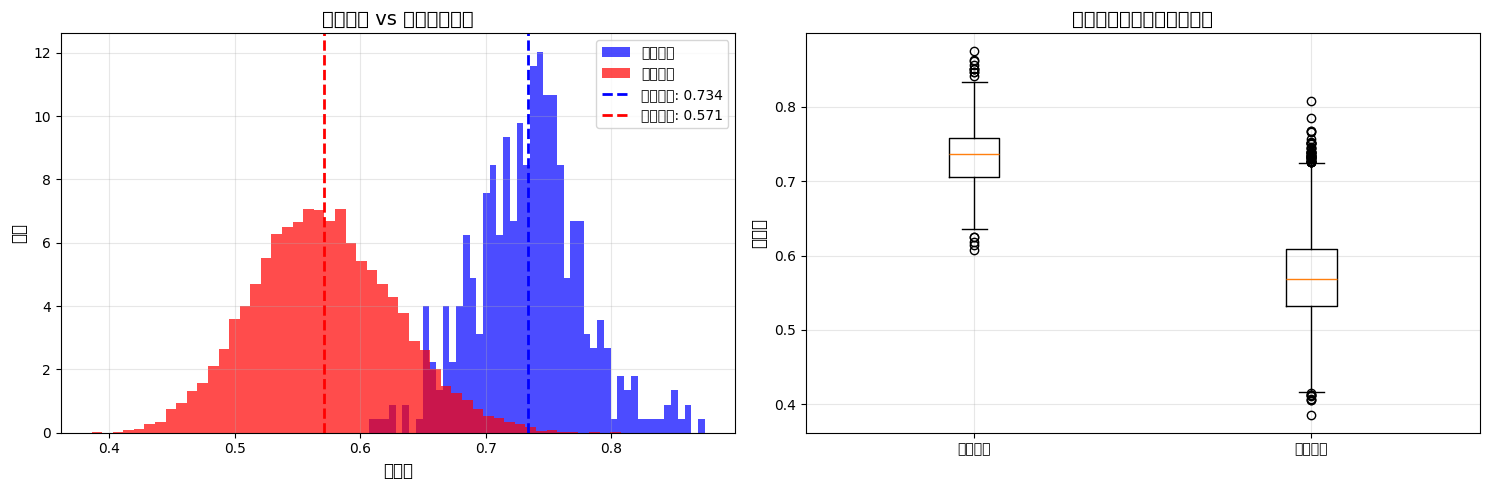


真实结果与随机基准的比值: 1.29x
(如果比值接近1，说明结果可能不可信；比值越大，说明重建质量越好)


In [83]:
# ====== 计算随机基准并对比 ======
# 计算随机颜色之间的相似度基准（使用与process_pdf相同的参数）
baseline = calculate_random_similarity_baseline(
    n_colors=5,  # 与process_pdf中使用的n_colors一致
    n_samples=10000,  # 采样次数，越多越准确
    method='delta_e',  # 与process_pdf中使用的method一致（如果使用LAB空间）
    color_space='LAB'  # 与process_pdf中使用的color_space一致
)

# 与真实结果对比（会自动从results中获取color_space和method，如果未提供baseline）
comparison = compare_with_random_baseline(
    results=results,
    baseline=baseline,  # 如果为None，会自动计算，使用results中的参数
    visualize=True
)

print(f"\n真实结果与随机基准的比值: {comparison['ratio']:.2f}x")
print(f"(如果比值接近1，说明结果可能不可信；比值越大，说明重建质量越好)")

In [88]:
real_similarities = []
for page_result in results['pages']:
    for recon in page_result['reconstructions']:
        real_similarities.append(recon['similarity'])
real_similarities = np.array(real_similarities)

baseline_similarities = baseline['all_similarities']

In [103]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns

with PdfPages('/media/ubuntu/sda/Monkey/scale_1_similarity_histplots.pdf') as pdf:
    plt.figure(figsize=(4, 2))
    sns.histplot(real_similarities, color= '#ED7B85', stat='density', bins=30,  edgecolor=None)
    sns.histplot(baseline_similarities, color='#5E9FD1', stat='density', bins=30, edgecolor=None)
    pdf.savefig()
    plt.close()

In [99]:
from scipy.stats import ttest_ind

# 执行t检验
t_stat, p_value = ttest_ind(real_similarities, baseline_similarities)

print(f"T统计量: {t_stat:.4f}")
print(f"P值: {p_value:.4f}")

# 判断显著性
alpha = 0.05
if p_value < alpha:
    print("结果显著：两组数据有显著差异")
else:
    print("结果不显著：两组数据没有显著差异")

T统计量: 58.2811
P值: 0.0000
结果显著：两组数据有显著差异
